# 09i — MOL00583–EGFR: analisi energetica endpoint
**PEARL Pipeline 5 · successivo a 09h · Jupyter / Python (PEARL MD 09h)**

Si analizza il run da 1 ns, non quello di test da 50 ps. Non si ripete la MD e non si ricalcolano cariche AM1-BCC. MOL00583 è il TIER_1_PRIMARY_COMPUTATIONAL_LEAD storico selezionato in 09g, con provenienza NEAR_MISS_MANDATORY_ONLY / NEAR_MISS_RESCUE, non validato sperimentalmente. Successive analisi A24–A26b hanno mostrato che la posa 09e/09f propagata a 09h è esterna alla nativa interfaccia EGF–EGFR e che MOL00583 non contatta tale interfaccia in nessuno dei 400 frame analizzati della traiettoria production dopo lo scarto iniziale. Di conseguenza, il presente endpoint energetico descrive la configurazione EGFR–MOL00583 campionata nella regione off-site di 09h e non deve essere interpretato come energia di interazione di MOL00583 nel sito EGF.

In [1]:
from pathlib import Path
import os, sys, json, hashlib, time, platform
from datetime import datetime, timezone
import numpy as np
import pandas as pd

def require(ok, message):
    if not ok: raise RuntimeError(message)
def dump(path, obj):
    Path(path).write_text(json.dumps(obj,indent=2,default=str),encoding='utf-8')
def sha(path):
    h=hashlib.sha256()
    with Path(path).open('rb') as f:
        for b in iter(lambda:f.read(1024*1024),b''):h.update(b)
    return h.hexdigest()

PROJECT_ROOT = Path.home()/'Desktop/venv' # modificabile; non si cerca il run piu recente
RUN_09H_NAME = '20260912T174721_843455Z_seed20260912'
INPUT_RUN = PROJECT_ROOT/'outputs/pipeline_5_pharmacophore_09h_mol00583_md'/RUN_09H_NAME
OUTPUT_BASE = Path.cwd()/'outputs/pipeline_5_pharmacophore_09i_mol00583_endpoint'
#RUN_ENERGY = False
RUN_ENERGY = True
#FAST_TEST_MODE = True
FAST_TEST_MODE = False
N_SNAPSHOTS = 3 if FAST_TEST_MODE else 50
DISCARD_FRACTION = 0.20
SOLUTE_DIELECTRIC = 1.0
SOLVENT_DIELECTRIC = 78.5
KAPPA_NM_INV = 0.0 # come 07e; non equivale a sale implicito 0.15 M
PLATFORM = 'CPU' # OpenCL non operativo nel kernel verificato
CPU_THREADS = 4 # ridurre se il Mac deve restare disponibile per altro
N_BLOCKS = 5
CANDIDATE='MOL00583'
TIER='TIER_1_PRIMARY_COMPUTATIONAL_LEAD'

## 1. Input e provenienza
Si richiedono manifest 09i, riepilogo e QC 09h, sistema fisico XML, mappa atomica e bond. La traiettoria del soluto è l'export non allineato dello stesso run; gli indici sono verificati contro la topologia completa e i parametri XML. I file originali non vengono modificati.

In [2]:
required = ['09i_manifest.json','09h_summary.json','provenance.json','tables/09h_QC.csv',
 'states/physical_system.xml','tables/solute_atom_map.csv','tables/solute_bonds.json',
 'structures/solvated.pdb','trajectories/production_solute.dcd',
 'inputs/ligand_openff.json']
for name in required:require((INPUT_RUN/name).is_file(),f'Input obbligatorio assente: {INPUT_RUN/name}')
manifest=json.loads((INPUT_RUN/'09i_manifest.json').read_text())
summary09h=json.loads((INPUT_RUN/'09h_summary.json').read_text())
prov09h=json.loads((INPUT_RUN/'provenance.json').read_text())
require(summary09h['mode']=='production' and summary09h['production_ps']>=1000,
        'Serve il run 09h di produzione >=1 ns, non il test da 50 ps.')
require(summary09h['candidate']==CANDIDATE and summary09h['tier']==TIER,
        'Identita/tier 09h incompatibili.')
require(summary09h['experimentally_validated'] is False and summary09h['technical_qc_pass'] is True,
        'Provenienza o QC 09h incompatibili.')
require(prov09h['status']=='analysis_completed','09h non completato.')
lead=prov09h['lead09g']
require(lead['pharmacophore_status']=='NEAR_MISS_MANDATORY_ONLY' and lead['docking_track']=='NEAR_MISS_RESCUE',
        'Provenienza farmacoforica inattesa.')
qc09h=pd.read_csv(INPUT_RUN/'tables/09h_QC.csv',dtype=str)
require(len(qc09h)>0 and qc09h['pass'].str.lower().eq('true').all(),'QC 09h non superati.')
require(manifest['index_base']==0 and manifest['production_restraints'] is False,'Manifest non compatibile.')
require(manifest['candidate']==CANDIDATE and manifest['physical_system']=='states/physical_system.xml',
        'Manifest non coerente con i file previsti.')
require(0<=DISCARD_FRACTION<1 and N_SNAPSHOTS>=3,'Configurazione campionamento non valida.')
print('Input verificati:',INPUT_RUN)
print('MD sorgente:',summary09h['production_ps'],'ps; endpoint richiesti:',N_SNAPSHOTS)
print('Nessuna nuova MD; nessuna installazione automatica.')
require(RUN_ENERGY,'Preflight completato. Impostare RUN_ENERGY=True per procedere.')

Input verificati: /Users/robertobruzzese/Desktop/venv/outputs/pipeline_5_pharmacophore_09h_mol00583_md/20260912T174721_843455Z_seed20260912
MD sorgente: 1000.0 ps; endpoint richiesti: 50
Nessuna nuova MD; nessuna installazione automatica.


## 2. Ambiente, mappa atomica e controlli del sistema
GBn2 è costruito con la stessa classe OpenMM usata da `implicit/gbn2.xml`. L'API interna è registrata e il file implementativo viene conservato tramite hash. La chimica del ligando non viene ricostruita dal PDB: si usano cariche, sigma ed epsilon del sistema 09h.

Per un complesso non covalente con geometrie identiche nei tre componenti, i termini legati e quelli non legati intramolecolari si cancellano in C−R−L. Si calcola quindi direttamente l'interazione Coulomb/Lennard-Jones recettore–ligando, evitando di sottrarre grandi energie intramolecolari. Si interrompe in presenza di forze non supportate, legami/termini covalenti o eccezioni tra recettore e ligando.

In [3]:
import openmm as mm
from openmm import app, unit
from openmm.app.internal import customgbforces
from openmm.app.internal.customgbforces import GBSAGBn2Force
import mdtraj as mt
import matplotlib.pyplot as plt
import inspect, importlib.metadata

RUN=OUTPUT_BASE/(datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S_%fZ')+('_test' if FAST_TEST_MODE else '_production'))
RUN.mkdir(parents=True,exist_ok=False)
for sub in ['tables','states','plots']: (RUN/sub).mkdir()
settings={k:v for k,v in list(globals().items()) if k.isupper() and isinstance(v,(str,int,float,bool,Path))}
provenance={'candidate':CANDIDATE,'tier':TIER,'experimentally_validated':False,
 'lead09g':lead,'source09h':summary09h,'config':settings,'status':'preparing',
 'python':sys.version,'platform':platform.platform(),
 'versions':{n:importlib.metadata.version(n) for n in ['openmm','mdtraj','numpy','pandas']},
 'gb_implementation_sha256':sha(inspect.getfile(customgbforces)),
 'inputs':{n:{'path':str(INPUT_RUN/n),'sha256':sha(INPUT_RUN/n)} for n in required}}
dump(RUN/'provenance.json',provenance)
physical=mm.XmlSerializer.deserialize((INPUT_RUN/'states/physical_system.xml').read_text())
pdb=app.PDBFile(str(INPUT_RUN/'structures/solvated.pdb'))
atommap=pd.read_csv(INPUT_RUN/'tables/solute_atom_map.csv',keep_default_na=False)
bonds=json.loads((INPUT_RUN/'tables/solute_bonds.json').read_text())
R=np.array(manifest['receptor_indices'],dtype=int); L=np.array(manifest['ligand_indices'],dtype=int)
S=np.sort(np.r_[R,L]); n=len(S)
require(len(set(S))==n and np.array_equal(S,np.arange(n)), 'Indici soluto non univoci/contigui: adattamento esplicito richiesto.')
require(np.array_equal(atommap['index'].to_numpy(),S),'Mappa atomi incompatibile.')
require(len(R)>0 and len(L)>0 and set(atommap.iloc[R].component)=={'EGFR'} and
        set(atommap.iloc[L].component)=={CANDIDATE},'Componenti errati.')
fullatoms=list(pdb.topology.atoms())
require(len(fullatoms)==physical.getNumParticles(),'Topologia completa e sistema non coincidono.')
for row in atommap.itertuples():
    a=fullatoms[row.index]
    require(a.name==row.name and a.element.symbol==row.element and a.residue.name==row.residue_name,
            f'Ordine atomico incompatibile: {row.index}')
require(not any(physical.isVirtualSite(i) for i in S),'Virtual sites non supportati in questo protocollo.')
Rset,Lset=set(R),set(L)
def cross(indices):
    return bool(set(indices)&Rset) and bool(set(indices)&Lset)
for a,b in bonds:require(not cross([a,b]),'Legame covalente recettore–ligando: protocollo non applicabile.')
allowed={'HarmonicBondForce','HarmonicAngleForce','PeriodicTorsionForce','NonbondedForce','CMMotionRemover'}
require(all(type(f).__name__ in allowed for f in physical.getForces()),'Forze non supportate nel sistema sorgente.')
for force in physical.getForces():
    if isinstance(force,mm.HarmonicBondForce): terms=[force.getBondParameters(j)[:2] for j in range(force.getNumBonds())]
    elif isinstance(force,mm.HarmonicAngleForce): terms=[force.getAngleParameters(j)[:3] for j in range(force.getNumAngles())]
    elif isinstance(force,mm.PeriodicTorsionForce): terms=[force.getTorsionParameters(j)[:4] for j in range(force.getNumTorsions())]
    else: terms=[]
    require(not any(cross(t) for t in terms),'Termine legato fra componenti: cancellazione non valida.')
nonbonded=[f for f in physical.getForces() if isinstance(f,mm.NonbondedForce)]
require(len(nonbonded)==1,'Atteso un solo NonbondedForce.')
nbforce=nonbonded[0]
require(nbforce.getNumParticleParameterOffsets()==0 and nbforce.getNumExceptionParameterOffsets()==0,
        'Offset parametrici non supportati.')
for j in range(nbforce.getNumExceptions()):
    a,b,*_=nbforce.getExceptionParameters(j)
    require(not cross([a,b]),'Eccezione non legata tra R/L non supportata.')
q=[];sigma=[];epsilon=[]
for i in S:
    qi,si,ei=nbforce.getParticleParameters(int(i))
    q.append(qi.value_in_unit(unit.elementary_charge));sigma.append(si.value_in_unit(unit.nanometer))
    epsilon.append(ei.value_in_unit(unit.kilojoule_per_mole))
q,sigma,epsilon=map(np.array,[q,sigma,epsilon])
require(np.isfinite(np.r_[q,sigma,epsilon]).all(),'Parametri non finiti.')
# Ricostruzione topologica con bond dal JSON 09h, non da inferenze sul PDB.
top=app.Topology(); chain_lookup={};res_lookup={};newatoms=[]
for row in atommap.itertuples():
    if row.chain not in chain_lookup:chain_lookup[row.chain]=top.addChain(row.chain)
    key=row.residue_index
    if key not in res_lookup:
        res_lookup[key]=top.addResidue(row.residue_name,chain_lookup[row.chain],str(row.residue_id),str(row.insertion_code).strip())
    newatoms.append(top.addAtom(row.name,app.element.Element.getBySymbol(row.element),res_lookup[key]))
for a,b in bonds:top.addBond(newatoms[a],newatoms[b])
mdtop=mt.Topology.from_openmm(top)
trajectory=mt.load_dcd(str(INPUT_RUN/'trajectories/production_solute.dcd'),top=mdtop)
frame_ps=float(manifest['frame_interval_ps'])
require(trajectory.n_atoms==n and trajectory.n_frames==round(summary09h['production_ps']/frame_ps),
        'Traiettoria incompleta/topologia errata.')
require(np.isfinite(trajectory.xyz).all(),'Coordinate non finite.')
# Coordinate continue necessarie per NoCutoff. Non si riporta il ligando nel sito.
lengths=mt.compute_distances(trajectory,np.array(bonds,dtype=int),periodic=False)
require(lengths.max()<0.30,'Legami >3 Å: ricostruire la continuita PBC prima dell’endpoint.')
start=int(trajectory.n_frames*DISCARD_FRACTION)
require(N_SNAPSHOTS<=trajectory.n_frames-start,'Snapshot richiesti superiori ai frame disponibili.')
frames=np.linspace(start,trajectory.n_frames-1,N_SNAPSHOTS,dtype=int)
require(len(np.unique(frames))==N_SNAPSHOTS,'Frame duplicati.')
frame_table=pd.DataFrame({'frame_index_0':frames,'time_ps':(frames+1)*frame_ps})
frame_table.to_csv(RUN/'tables/selected_frames.csv',index=False)
print('Frame selezionati:',frames,'; cartella:',RUN)

Frame selezionati: [100 108 116 124 132 140 148 157 165 173 181 189 197 205 214 222 230 238
 246 254 262 271 279 287 295 303 311 319 328 336 344 352 360 368 376 385
 393 401 409 417 425 433 442 450 458 466 474 482 490 499] ; cartella: /Users/robertobruzzese/Desktop/venv/outputs/pipeline_5_pharmacophore_09i_mol00583_endpoint/20260913T104616_464776Z_production


## 3. GBn2/ACE e parametri per tutti i componenti
I raggi GBn2 (mbondi3), fattori di schermatura e coefficienti sono derivati una sola volta dalla topologia completa del soluto, poi conservati nei componenti separati. Per il ligando si applicano le regole elementari/topologiche OpenMM GBn2: non sono una calibrazione specifica dell'affinità di MOL00583.

Due forze GB per componente permettono di separare il termine polare da ACE tramite differenza. Tre componenti: complesso C, recettore R, ligando L. Nessuna minimizzazione dei frame. Il solvente esplicito e gli ioni sono esclusi dal calcolo energetico; kappa=0 riprende il default di 07e, pur provenendo da MD in NaCl 0,15 M.

In [4]:
gbparams=np.asarray(GBSAGBn2Force.getStandardParameters(top),dtype=float)
require(gbparams.shape==(n,5) and np.isfinite(gbparams).all() and (gbparams[:,0]>0).all(),
        'Parametri GBn2 non validi.')
params=atommap.copy()
params['charge_e']=q;params['sigma_nm']=sigma;params['epsilon_kJ_mol']=epsilon
for j,name in enumerate(['radius_nm','screen','alpha','beta','gamma']):params[name]=gbparams[:,j]
params.to_csv(RUN/'tables/endpoint_atom_parameters.csv',index=False)
contexts={}; systems={}; integrators={}
platform_mm=mm.Platform.getPlatformByName(PLATFORM)
for name,indices in {'C':S,'R':R,'L':L}.items():
    system=mm.System()
    for idx in indices:system.addParticle(physical.getParticleMass(int(idx)))
    for group,sa in [(0,None),(1,'ACE')]:
        force=GBSAGBn2Force(solventDielectric=SOLVENT_DIELECTRIC,
              soluteDielectric=SOLUTE_DIELECTRIC,SA=sa,cutoff=None,kappa=KAPPA_NM_INV)
        for idx in indices:force.addParticle([float(q[idx])]+gbparams[idx].tolist())
        force.finalize();force.setForceGroup(group);system.addForce(force)
    integrators[name]=mm.VerletIntegrator(0.001*unit.picosecond)
    contexts[name]=mm.Context(system,integrators[name],platform_mm,{'Threads':str(CPU_THREADS)} if PLATFORM=='CPU' else {})
    systems[name]=system
    (RUN/f'states/{name}_GBn2_analysis_only.xml').write_text(mm.XmlSerializer.serialize(system))
# These systems contain TWO GB forces for separate evaluation, no MM force.
# Never integrate them or read their sum as the physical energy.

def gb_energy(name,xyz):
    ctx=contexts[name];ctx.setPositions(xyz*unit.nanometer)
    polar=ctx.getState(getEnergy=True,groups={0}).getPotentialEnergy().value_in_unit(unit.kilojoule_per_mole)
    total=ctx.getState(getEnergy=True,groups={1}).getPotentialEnergy().value_in_unit(unit.kilojoule_per_mole)
    return float(polar),float(total-polar)

def cross_mm(xyz):
    distances=np.linalg.norm(xyz[R,None,:]-xyz[L][None,:,:],axis=2)
    require(np.isfinite(distances).all() and distances.min()>0.05,'Distanze R/L non valide.')
    sig=(sigma[R,None]+sigma[L][None,:])/2
    eps=np.sqrt(epsilon[R,None]*epsilon[L][None,:])
    sr6=(sig/distances)**6
    lj=np.sum(4*eps*(sr6*sr6-sr6))
    coul=138.93545764438198*np.sum(q[R,None]*q[L][None,:]/distances)
    require(SOLUTE_DIELECTRIC==1.0,'MM implementato per dielettrico interno 1: non modificarlo senza adattare MM.')
    return float(coul),float(lj)
print('Sistemi GBn2 pronti; nessun uso di AmberTools richiesto in 09i.')

Sistemi GBn2 pronti; nessun uso di AmberTools richiesto in 09i.


## 4. Verifica indipendente MM e calcolo con avanzamento
Sul primo snapshot si confronta il risultato analitico R–L con un NonbondedForce OpenMM (C−R−L), usando cariche, regole Lorentz–Berthelot ed eccezioni ereditate da 09h. Questo controllo verifica unità, indici e cancellazione intramolecolare.

Ogni snapshot viene scritto immediatamente nel CSV. In caso di errore, il run resta esplicitamente incompleto. Non è implementato un resume automatico: riavviare tutto crea una nuova cartella.

In [5]:
def independent_mm(indices,xyz):
    mapping={int(old):new for new,old in enumerate(indices)}
    system=mm.System();force=mm.NonbondedForce();force.setNonbondedMethod(mm.NonbondedForce.NoCutoff)
    force.setUseDispersionCorrection(False)
    for old in indices:
        system.addParticle(physical.getParticleMass(int(old)))
        force.addParticle(q[old],sigma[old],epsilon[old])
    for j in range(nbforce.getNumExceptions()):
        a,b,c,s,e=nbforce.getExceptionParameters(j)
        if a in mapping and b in mapping:force.addException(mapping[a],mapping[b],c,s,e)
    system.addForce(force);integ=mm.VerletIntegrator(0.001)
    ctx=mm.Context(system,integ,mm.Platform.getPlatformByName('Reference'))
    ctx.setPositions(xyz[indices]*unit.nanometer)
    value=ctx.getState(getEnergy=True).getPotentialEnergy().value_in_unit(unit.kilojoule_per_mole)
    del ctx,integ
    return value
xyz=trajectory.xyz[frames[0]].astype(float)
analytic=sum(cross_mm(xyz))
independent=independent_mm(S,xyz)-independent_mm(R,xyz)-independent_mm(L,xyz)
mm_error=abs(analytic-independent)
require(mm_error<0.05,f'Verifica MM fallita: differenza {mm_error} kJ/mol.')
dump(RUN/'tables/MM_validation.json',{'analytic_kJ_mol':analytic,'OpenMM_kJ_mol':independent,'absolute_error_kJ_mol':mm_error})
print('Verifica MM superata; errore:',mm_error,'kJ/mol',flush=True)
rows=[];t0=time.monotonic()
provenance['status']='running';dump(RUN/'provenance.json',provenance)
try:
    for count,j in enumerate(frames,1):
        xyz=trajectory.xyz[j].astype(float)
        elec,vdw=cross_mm(xyz)
        energy={name:gb_energy(name,xyz[indices]) for name,indices in {'C':S,'R':R,'L':L}.items()}
        polar=energy['C'][0]-energy['R'][0]-energy['L'][0]
        sa=energy['C'][1]-energy['R'][1]-energy['L'][1]
        row={'frame_index_0':int(j),'time_ps':float((j+1)*frame_ps),
             'MM_electrostatic':elec/4.184,'MM_vdw':vdw/4.184,'delta_GB_polar':polar/4.184,
             'delta_SA_ACE':sa/4.184,'endpoint_proxy':(elec+vdw+polar+sa)/4.184}
        for name in energy:
            row[name+'_GB_polar']=energy[name][0]/4.184;row[name+'_SA_ACE']=energy[name][1]/4.184
        require(np.isfinite(list(row.values())).all(),f'Energie non finite al frame {j}.')
        rows.append(row);pd.DataFrame(rows).to_csv(RUN/'tables/endpoint_per_frame_kcal_mol.csv',index=False)
        elapsed=time.monotonic()-t0;remaining=elapsed/count*(len(frames)-count)
        print(f'{count}/{len(frames)} ({100*count/len(frames):.0f}%) | {row["time_ps"]:.0f} ps | '
              f'endpoint {row["endpoint_proxy"]:.2f} kcal/mol | residuo stimato {remaining/60:.1f} min',flush=True)
except Exception as exc:
    provenance.update(status='failed',error=repr(exc),completed_snapshots=len(rows));dump(RUN/'provenance.json',provenance)
    raise
finally:
    contexts.clear();integrators.clear()
energies=pd.DataFrame(rows)

Verifica MM superata; errore: 1.1261818144703284e-09 kJ/mol
1/50 (2%) | 202 ps | endpoint -22.35 kcal/mol | residuo stimato 6.7 min
2/50 (4%) | 218 ps | endpoint -20.52 kcal/mol | residuo stimato 6.6 min
3/50 (6%) | 234 ps | endpoint -18.60 kcal/mol | residuo stimato 6.4 min
4/50 (8%) | 250 ps | endpoint -20.02 kcal/mol | residuo stimato 6.3 min
5/50 (10%) | 266 ps | endpoint -20.28 kcal/mol | residuo stimato 6.2 min
6/50 (12%) | 282 ps | endpoint -22.27 kcal/mol | residuo stimato 6.0 min
7/50 (14%) | 298 ps | endpoint -22.03 kcal/mol | residuo stimato 5.9 min
8/50 (16%) | 316 ps | endpoint -24.18 kcal/mol | residuo stimato 5.7 min
9/50 (18%) | 332 ps | endpoint -21.77 kcal/mol | residuo stimato 5.6 min
10/50 (20%) | 348 ps | endpoint -20.09 kcal/mol | residuo stimato 5.5 min
11/50 (22%) | 364 ps | endpoint -23.35 kcal/mol | residuo stimato 5.3 min
12/50 (24%) | 380 ps | endpoint -16.66 kcal/mol | residuo stimato 5.2 min
13/50 (26%) | 396 ps | endpoint -24.60 kcal/mol | residuo stimato

## 5. Riepilogo, variabilità e QC
Media e deviazione standard descrivono i frame campionati; la SD non è l'incertezza della media. Frame correlati di una sola traiettoria non sono repliche indipendenti: niente SEM ingenua o intervalli di confidenza presentati come validati. Le medie per blocchi temporali e per metà aiutano a rilevare deriva; non provano convergenza. Il segno negativo indica favorevolezza energetica entro questo modello e per la configurazione strutturale campionata, non prova binding. A26b ha inoltre mostrato che la traiettoria 09h sorgente rimane esterna alla nativa interfaccia EGF–EGFR per tutti i 400 frame production analizzati dopo lo scarto iniziale. Pertanto, il valore endpoint di 09i caratterizza l'interazione EGFR–MOL00583 nella regione off-site campionata da 09h e non costituisce evidenza energetica di binding al sito EGF.

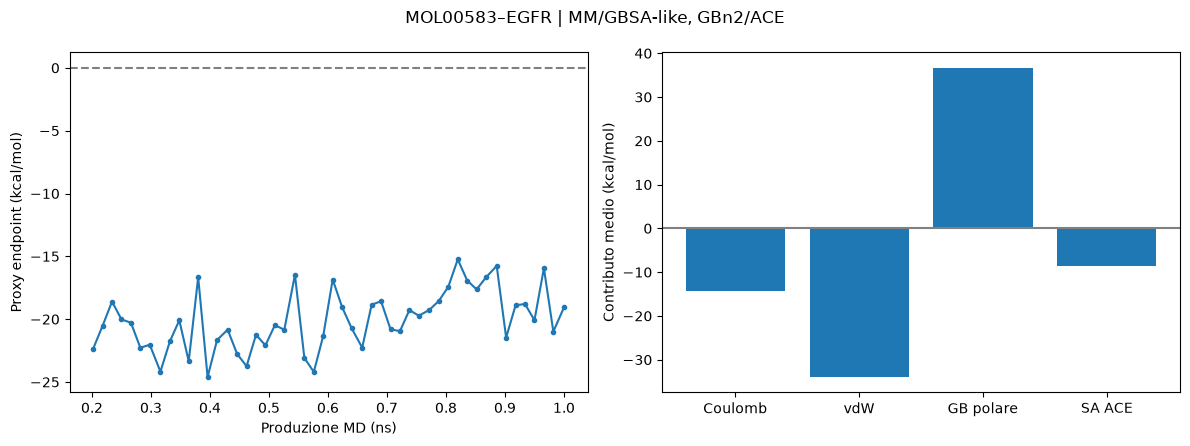

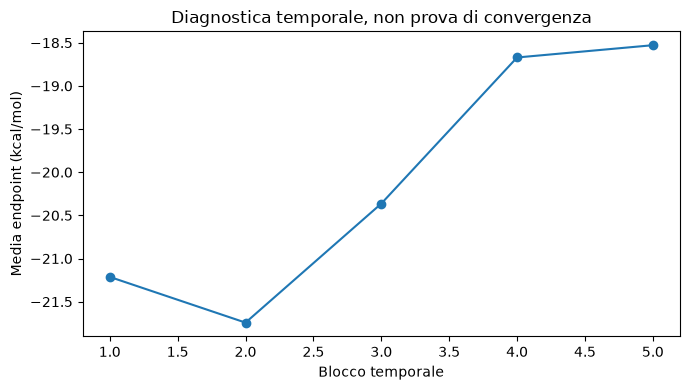

,mean,std,min,max
component_kcal_mol,,,,
MM_electrostatic,-14.288388,4.701548,-29.310529,-4.504430
MM_vdw,-33.960405,3.512929,-39.593069,-24.506873
delta_GB_polar,36.665285,4.626427,25.919086,49.074351
delta_SA_ACE,-8.520059,0.693710,-9.683468,-6.797602
endpoint_proxy,-20.103566,2.371347,-24.604553,-15.239928


{
  "candidate": "MOL00583",
  "tier": "TIER_1_PRIMARY_COMPUTATIONAL_LEAD",
  "experimentally_validated": false,
  "mode": "production",
  "n_snapshots": 50,
  "source_MD_ps": 1000.0,
  "GB_model": "GBn2",
  "SA_model": "ACE",
  "mean_endpoint_kcal_mol": -20.103566200344154,
  "SD_across_correlated_snapshots_kcal_mol": 2.3713474959933207,
  "half_means_kcal_mol": {
    "first_half_mean": -21.418653155848915,
    "second_half_mean": -18.788479244839394
  },
  "technical_qc_pass": true,
  "interpretation": "Proxy single-trajectory senza entropia; non DeltaG rigorosa, non affinita sperimentale, non ranking."
}
Output: /Users/robertobruzzese/Desktop/venv/outputs/pipeline_5_pharmacophore_09i_mol00583_endpoint/20260913T104616_464776Z_production


In [6]:
columns=['MM_electrostatic','MM_vdw','delta_GB_polar','delta_SA_ACE','endpoint_proxy']
stats=energies[columns].agg(['mean','std','min','max']).T
stats.index.name='component_kcal_mol';stats.to_csv(RUN/'tables/energy_summary.csv')
block_rows=[]
if len(energies)>=2*N_BLOCKS:
    for k,idx in enumerate(np.array_split(np.arange(len(energies)),N_BLOCKS),1):
        block_rows.append(dict(block=k,time_start_ps=energies.iloc[idx].time_ps.min(),
          time_end_ps=energies.iloc[idx].time_ps.max(),n=len(idx),
          endpoint_mean_kcal_mol=energies.iloc[idx].endpoint_proxy.mean()))
blocks=pd.DataFrame(block_rows)
blocks.to_csv(RUN/'tables/temporal_blocks.csv',index=False)
mid=len(energies)//2
halves={'first_half_mean':float(energies.iloc[:mid].endpoint_proxy.mean()),
        'second_half_mean':float(energies.iloc[mid:].endpoint_proxy.mean())}
qc={'all_requested_snapshots':len(energies)==N_SNAPSHOTS,'finite_energies':bool(np.isfinite(energies[columns]).all().all()),
    'MM_independent_validation':mm_error<0.05,
    'sum_components_matches':bool(np.allclose(energies[columns[:-1]].sum(axis=1),energies.endpoint_proxy,atol=1e-6))}
pd.DataFrame([{'check':k,'pass':v} for k,v in qc.items()]).to_csv(RUN/'tables/09i_QC.csv',index=False)
fig,axes=plt.subplots(1,2,figsize=(12,4.5))
axes[0].plot(energies.time_ps/1000,energies.endpoint_proxy,'o-',ms=3)
axes[0].axhline(0,color='gray',ls='--');axes[0].set(xlabel='Produzione MD (ns)',ylabel='Proxy endpoint (kcal/mol)')
axes[1].bar(['Coulomb','vdW','GB polare','SA ACE'],stats.loc[columns[:-1],'mean'])
axes[1].axhline(0,color='gray');axes[1].set_ylabel('Contributo medio (kcal/mol)')
fig.suptitle('MOL00583–EGFR | MM/GBSA-like, GBn2/ACE');fig.tight_layout()
fig.savefig(RUN/'plots/09i_endpoint.png',dpi=240);plt.show()
if not blocks.empty:
    fig,ax=plt.subplots(figsize=(7,4));ax.plot(blocks.block,blocks.endpoint_mean_kcal_mol,'o-')
    ax.set(xlabel='Blocco temporale',ylabel='Media endpoint (kcal/mol)',title='Diagnostica temporale, non prova di convergenza')
    fig.tight_layout();fig.savefig(RUN/'plots/09i_blocks.png',dpi=200);plt.show()
result={'candidate':CANDIDATE,'tier':TIER,'experimentally_validated':False,
 'mode':'smoke_test' if FAST_TEST_MODE else 'production','n_snapshots':len(energies),
 'source_MD_ps':summary09h['production_ps'],'GB_model':'GBn2','SA_model':'ACE',
 'mean_endpoint_kcal_mol':float(stats.loc['endpoint_proxy','mean']),
 'SD_across_correlated_snapshots_kcal_mol':float(stats.loc['endpoint_proxy','std']),
 'half_means_kcal_mol':halves,'technical_qc_pass':all(qc.values()),
 'interpretation':'Proxy single-trajectory senza entropia; non DeltaG rigorosa, non affinita sperimentale, non ranking.'}
dump(RUN/'09i_summary.json',result)
report=f"""# 09i — MOL00583–EGFR: endpoint MM/GBSA-like

Modalita: {result['mode']}. Snapshot: {len(energies)} dal run 09h di {summary09h['production_ps']} ps.
Modello: GBn2/ACE, dielettrici {SOLUTE_DIELECTRIC}/{SOLVENT_DIELECTRIC}, kappa {KAPPA_NM_INV} nm^-1.
Media endpoint: {result['mean_endpoint_kcal_mol']:.3f} kcal/mol.
SD tra snapshot correlati: {result['SD_across_correlated_snapshots_kcal_mol']:.3f} kcal/mol (non SEM).
Medie nelle due meta: {halves}.
QC tecnico: {all(qc.values())}.

Il calcolo conserva i parametri 09h e non include entropia o rilassamento separato.
Non e una misura sperimentale o una energia libera rigorosa di binding.
II valori vanno letti insieme a RMSD, contatti e analisi di sito 09h e alla variabilita temporale.
A26b ha mostrato che la traiettoria 09h production non contatta la nativa interfaccia EGF-EGFR nei 400 frame analizzati dopo lo scarto iniziale; questo endpoint descrive quindi la configurazione off-site campionata e non evidenza energetica di binding al sito EGF.
Un run test di tre snapshot verifica esclusivamente l'esecuzione del metodo.
MOL00583 e conservato come TIER_1_PRIMARY_COMPUTATIONAL_LEAD storico selezionato in 09g, non come lead primario riassegnato dopo A24-A26b, ed e non validato sperimentalmente,
con provenienza NEAR_MISS_MANDATORY_ONLY / NEAR_MISS_RESCUE.
"""
(RUN/'09i_report.md').write_text(report,encoding='utf-8')
provenance.update(status='completed',result=result);dump(RUN/'provenance.json',provenance)
dump(RUN/'artifact_sha256.json',{str(p.relative_to(RUN)):sha(p) for p in sorted(RUN.rglob('*')) if p.is_file()})
display(stats);print(json.dumps(result,indent=2));print('Output:',RUN)

## Riferimenti e limiti operativi
Metodo precedente verificato nel notebook locale 07e (modello selezionato: `implicit/gbn2.xml`). Implementazione verificata nel file `openmm/app/data/implicit/gbn2.xml` e `openmm/app/internal/customgbforces.py` dell'ambiente `pearl-09h`.

Documentazione: [OpenMM](https://docs.openmm.org/latest/userguide/application/02_running_sims.html), [codice GB OpenMM](https://github.com/openmm/openmm/blob/master/wrappers/python/openmm/app/internal/customgbforces.py).

Le topologie energetiche salvate contengono due forze GB per decomposizione: **non sono sistemi per MD** e la loro energia totale non va usata sommando i gruppi. Solo la funzione `gb_energy` restituisce le componenti corrette. Il termine MM e calcolato separatamente e validato con OpenMM.

Un successivo studio dovrebbe valutare repliche, durata, sensibilita a dielettrico/sale/modello GB e controlli comparativi prima di conclusioni su binding. La durata di 1 ns e il singolo microstato limitano l'interpretazione.